## DHM (Digital Holography Microscopy) Evaluation - TIE (Cheekcell)


In [811]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft2, ifft2, fftshift, ifftshift, fftfreq
import tifffile as tif
from skimage.feature import peak_local_max
from skimage.restoration import unwrap_phase
import cv2

### Import

Text(0.5, 1.0, 'Background image')

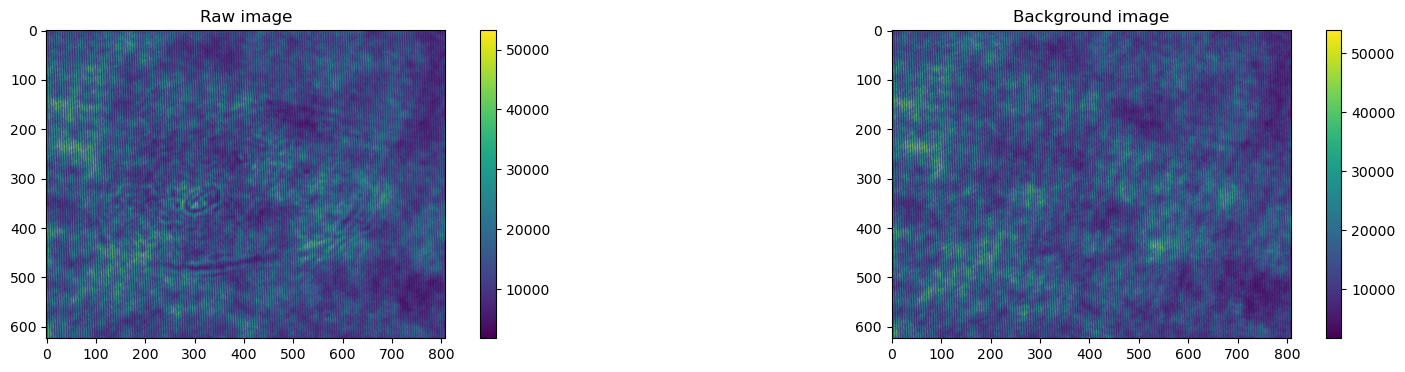

In [838]:
img_stack_raw = tif.imread(r"C:\Users\q082fh\Documents\TIE\Measurements\Measurements with DHM\2025.05.02\cheek-02\test_sequence_18_MMStack_Pos0.ome.tif")
img_stack_bg = tif.imread(r"C:\Users\q082fh\Documents\TIE\Measurements\Measurements with DHM\2025.05.02\cheek-05\test_sequence_22_MMStack_Pos0.ome.tif")
img_stack_bg = tif.imread(r"C:\Users\q082fh\Documents\TIE\Measurements\Measurements with DHM\2025.05.02\cheek-03\test_sequence_19_MMStack_Pos0.ome.tif")
idx_foc = 10
img_raw = img_stack_raw[idx_foc]
img_bg = img_stack_bg[idx_foc]
img = img_raw


# img = img[0:620, 80:700]

plt.figure(figsize=(20, 4))
plt.subplot(121)
plt.imshow(img_raw)
plt.colorbar()
plt.title("Raw image")

plt.subplot(122)
plt.imshow(img_bg)
plt.colorbar()
plt.title("Background image")




### FFT - Peak Finding - Shifting

(3, 2)
(3, 2)


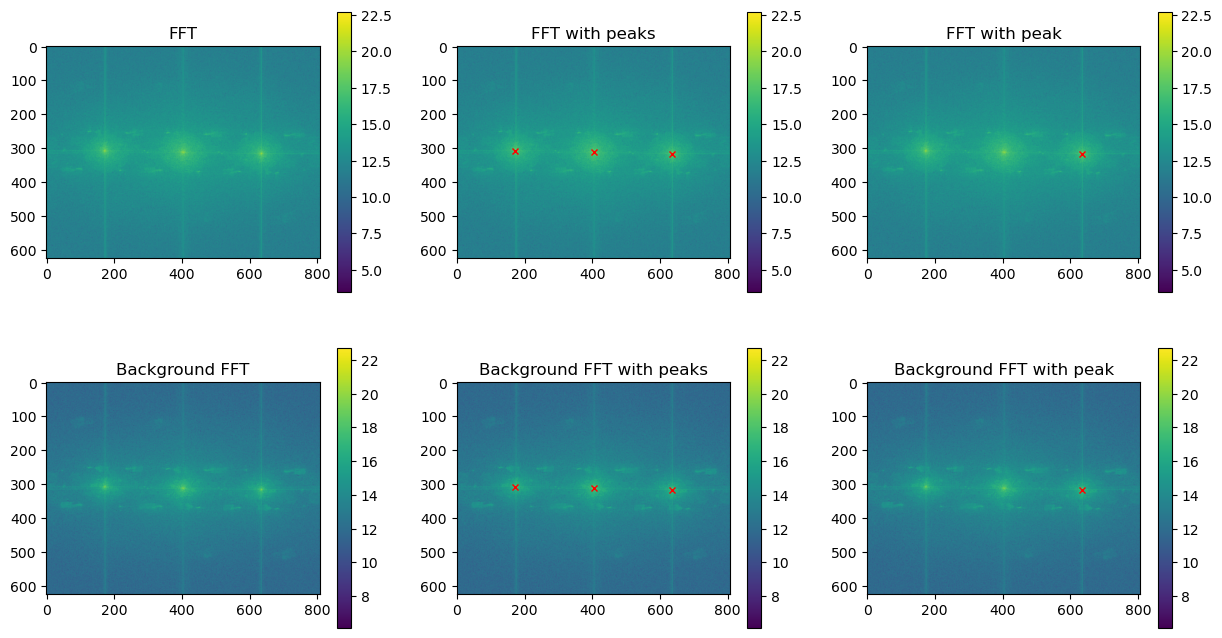

In [860]:
img_FFT = ifftshift(fft2(img))
img_bg_FFT = ifftshift(fft2(img_bg))

pks = peak_local_max(np.log(abs(img_FFT)), min_distance=100, threshold_abs=0.5)    
print(pks.shape)
pk = pks[2]

pks_bg = peak_local_max(np.log(abs(img_bg_FFT)), min_distance=100, threshold_abs=0.5)    
print(pks_bg.shape)
pk_bg = pks_bg[2]

plt.figure(figsize=(15, 8))

plt.subplot(231)
plt.imshow(np.log(abs((img_FFT))))
plt.title("FFT")
plt.colorbar()

plt.subplot(234)
plt.imshow(np.log(abs((img_bg_FFT))))
plt.title("Background FFT")
plt.colorbar()

plt.subplot(232)
plt.imshow(np.log(abs((img_FFT))))
plt.plot(pks[:,1], pks[:,0], "rx", markersize=5)
plt.title("FFT with peaks")
plt.colorbar()

plt.subplot(235)
plt.imshow(np.log(abs((img_bg_FFT))))
plt.plot(pks_bg[:,1], pks_bg[:,0], "rx", markersize=5)
plt.title("Background FFT with peaks")
plt.colorbar()


plt.subplot(233)
plt.imshow(np.log(abs((img_FFT))))
plt.plot(pk[1], pk[0], "rx", markersize=5)
plt.title("FFT with peak")
plt.colorbar()

plt.subplot(236)
plt.imshow(np.log(abs((img_bg_FFT))))
plt.plot(pk_bg[1], pk_bg[0], "rx", markersize=5)
plt.title("Background FFT with peak")
plt.colorbar()



231 4


Text(0.5, 1.0, 'Shifted background FFT')

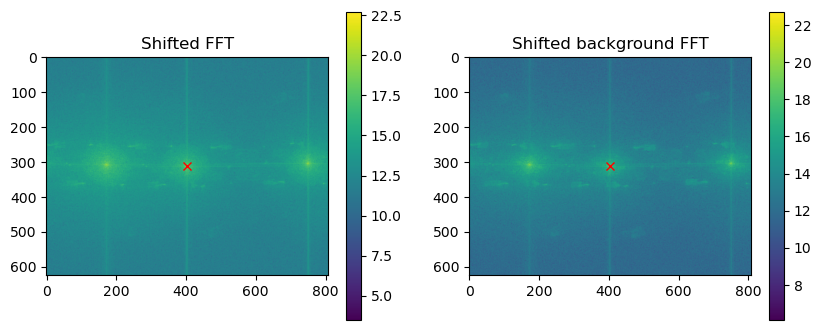

In [862]:
shift_x = abs (pk[1] - img_FFT.shape[1] // 2)
shift_y = abs(pk[0] - img_FFT.shape[0] // 2)
print(shift_x, shift_y)

img_FFT_shifted = np.roll(img_FFT, -shift_x, axis=1)
img_FFT_shifted = np.roll(img_FFT_shifted, -shift_y, axis=0)

shift_x_bg = abs (pk_bg[1] - img_FFT.shape[1] // 2)
shift_y_bg = abs(pk_bg[0] - img_FFT.shape[0] // 2)

img_bg_FFT_shifted = np.roll(img_bg_FFT, -shift_x_bg, axis=1)
img_bg_FFT_shifted = np.roll(img_bg_FFT_shifted, -shift_y_bg, axis=0)


plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.imshow(np.log(abs((img_FFT_shifted))))
plt.plot(img.shape[1]//2, img.shape[0]//2, "rx")
plt.colorbar()
plt.title("Shifted FFT")

plt.subplot(122)
plt.imshow(np.log(abs((img_bg_FFT_shifted))))
plt.plot(img.shape[1]//2, img.shape[0]//2, "rx")
plt.colorbar()
plt.title("Shifted background FFT")

### Cropping

In [863]:
# Parameters
lam = 640e-9  # wavelength in meters
NA = 0.4  # numerical aperture
M = 20*1.5  # magnification
pixel_size = 4.5e-6  # pixel size (Camera) in meters
dx = pixel_size / M  # pixel size in the image plane
dy = dx
k0 = 2*np.pi / lam  # wavenumber

nx = img.shape[1]  # number of pixels in x direction
ny = img.shape[0]  # number of pixels in y direction
x = (np.arange(nx) - nx/2)*dx
y = (np.arange(ny) - ny/2)*dy

X, Y = np.meshgrid(x, y)

kx = fftfreq(nx, dx)* 2 * np.pi  # spatial frequencies in x direction
ky = fftfreq(ny, dy)* 2 * np.pi  # spatial frequencies in y direction
Kx, Ky = np.meshgrid(kx, ky)  # meshgrid of spatial frequencies

C:\Users\q082fh\AppData\Local\Temp\ipykernel_14860\4179873447.py:7: RuntimeWarning: divide by zero encountered in log
  img_filtered_plot = np.where(img_filtered != 0, np.log(abs(img_filtered)), 0)
C:\Users\q082fh\AppData\Local\Temp\ipykernel_14860\4179873447.py:8: RuntimeWarning: divide by zero encountered in log
  img_bg_filtered_plot = np.where(img_bg_filtered != 0, np.log(abs(img_bg_filtered)), 0)


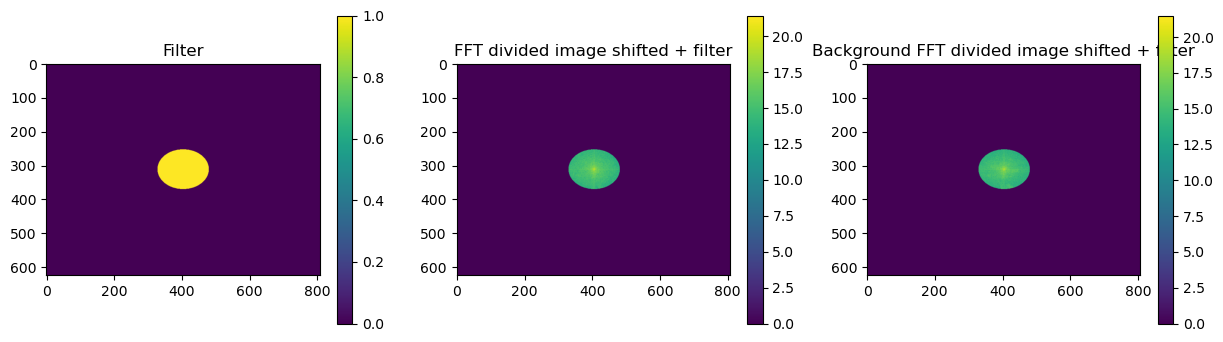

In [864]:
# defining the filter
radius = fftshift(np.sqrt(Kx**2 + Ky**2) < (k0*NA))  # circular aperture

img_filtered = img_FFT_shifted * radius  # apply the filter in the Fourier domain
img_bg_filtered = img_bg_FFT_shifted * radius  # apply the filter in the Fourier domain

img_filtered_plot = np.where(img_filtered != 0, np.log(abs(img_filtered)), 0)
img_bg_filtered_plot = np.where(img_bg_filtered != 0, np.log(abs(img_bg_filtered)), 0)

plt.figure(figsize=(15, 4))

plt.subplot(131)
plt.imshow(radius)
plt.title("Filter")
plt.colorbar()


plt.subplot(132)
plt.imshow(img_filtered_plot)
plt.title("FFT divided image shifted + filter")
plt.colorbar()

plt.subplot(133)
plt.imshow(img_bg_filtered_plot)
plt.title("Background FFT divided image shifted + filter")
plt.colorbar()

# plt.subplot(233)
# plt.imshow(np.log(abs((img_FFT_shifted[nx//2-50:nx//2+50 ,ny//2-50:ny//2+50]))))
# plt.title("FFT divided image shifted + squared filter")
# plt.colorbar()

plt.show()

### IFFT - Unwrapping

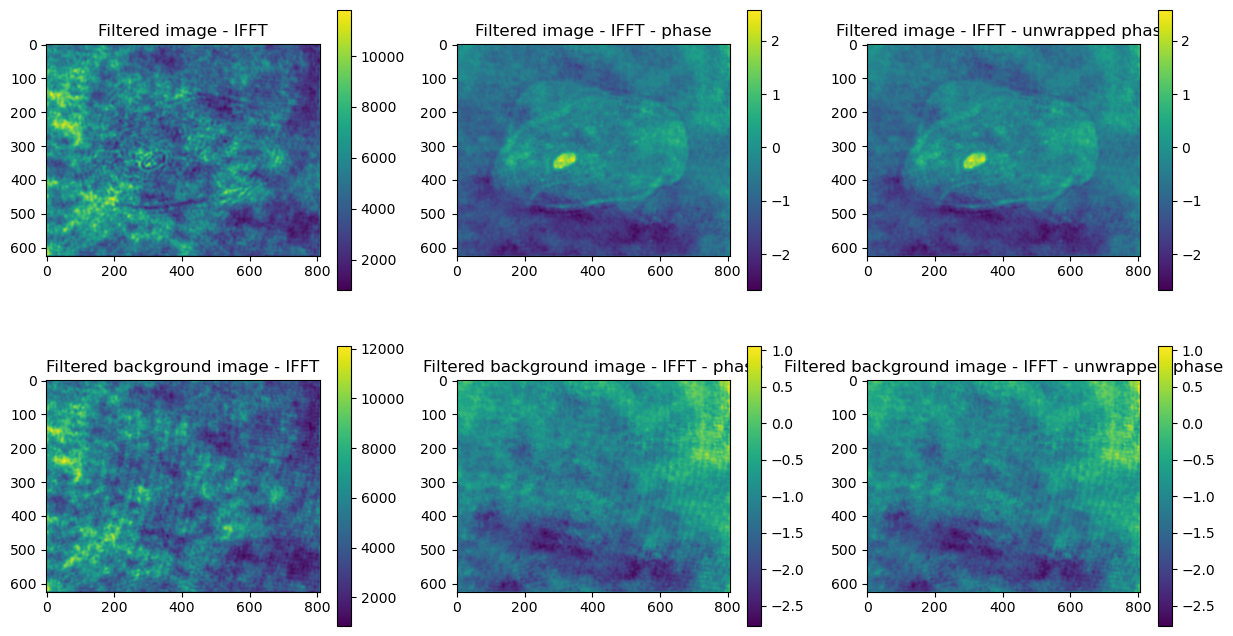

In [865]:
IF_img = ifft2(ifftshift(img_filtered))
IF_img_angle = np.angle(IF_img)
IF_img_unwrapped = unwrap_phase(IF_img_angle)

IF_img_bg = ifft2(ifftshift(img_bg_filtered))
IF_img_bg_angle = np.angle(IF_img_bg)
IF_img_bg_unwrapped = unwrap_phase(IF_img_bg_angle)


plt.figure(figsize=(15, 8))

plt.subplot(231)
plt.imshow(abs(IF_img))
plt.title("Filtered image - IFFT")
plt.colorbar()

plt.subplot(234)
plt.imshow(abs(IF_img_bg))
plt.title("Filtered background image - IFFT")
plt.colorbar()

plt.subplot(232)
plt.imshow((IF_img_angle))
plt.colorbar()
plt.title("Filtered image - IFFT - phase")

plt.subplot(235)
plt.imshow((IF_img_bg_angle))
plt.title("Filtered background image - IFFT - phase")
plt.colorbar()

plt.subplot(233)
plt.imshow((IF_img_unwrapped))
plt.colorbar()
plt.title("Filtered image - IFFT - unwrapped phase")

plt.subplot(236)
plt.imshow((IF_img_bg_unwrapped))
plt.title("Filtered background image - IFFT - unwrapped phase")
plt.colorbar()
plt.show()

### Result - Phase 

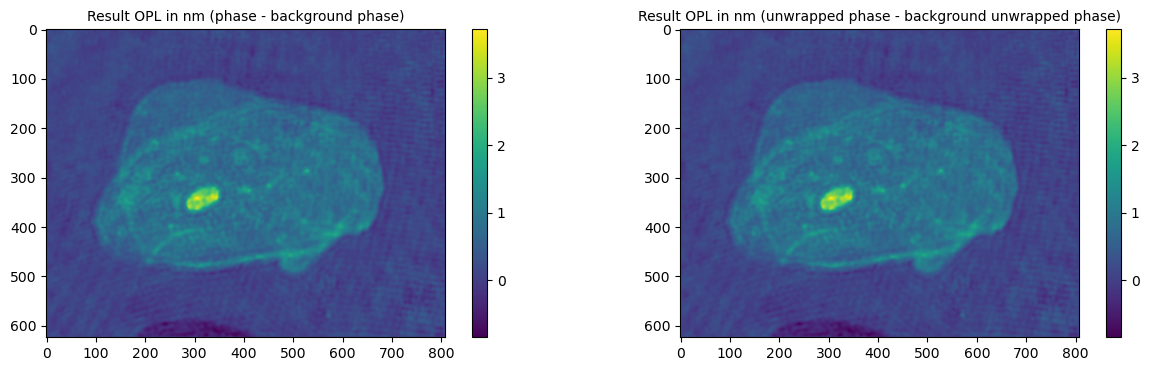

In [866]:
img_result_angle = (IF_img_angle - IF_img_bg_angle)#*(lam/(2*np.pi))*1e9
img_result_unwrapped = unwrap_phase(IF_img_unwrapped - IF_img_bg_unwrapped)#*(lam/(2*np.pi))*1e9

plt.figure(figsize=(15, 4))

plt.subplot(121)
plt.imshow(img_result_angle)
plt.title("Result OPL in nm (phase - background phase)", size=10)
plt.colorbar()

plt.subplot(122)
plt.imshow(img_result_unwrapped)
plt.title("Result OPL in nm (unwrapped phase - background unwrapped phase)", size=10)
plt.colorbar()

### Drymass calculation

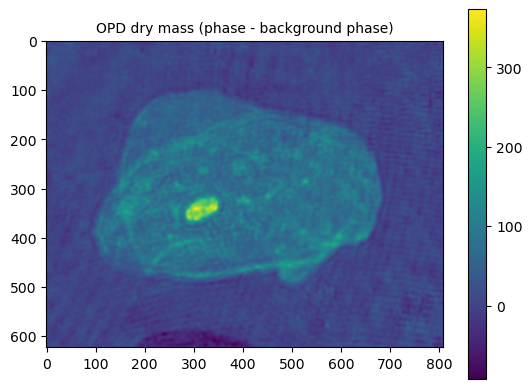

In [867]:
# mass calculation
alpha=1.90*1e-7

OPD_dry_mass = img_result_angle*(lam/(2*np.pi))*1e9

# subtracting the mean of the outer pixels
outer_mean = np.mean([OPD_dry_mass[0:2,:].mean(),OPD_dry_mass[-2:-1,:].mean(),
                        OPD_dry_mass[:,0:2].mean(),OPD_dry_mass[:,-2:-1].mean()])
OPD_dry_mass -= outer_mean


plt.imshow(OPD_dry_mass)
plt.title("OPD dry mass (phase - background phase)", size=10)
plt.colorbar()

In [846]:
sigma = OPD_dry_mass/alpha
mass = np.sum(sigma)*dx**2 #dry mass in gramm
print(np.round(mass, 5))

1.8163


### Contour Detection and Mass Calculation inside the Contour

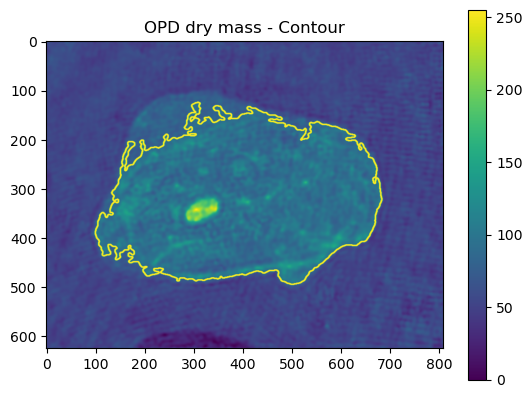

In [847]:
img_gray = img_gray_uint8 = cv2.normalize(OPD_dry_mass, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) #OPD_dry_mass.astype(np.uint64).copy()

ret, thresh = cv2.threshold(img_gray, thresh=82, maxval=np.amax(OPD_dry_mass), type=cv2.THRESH_BINARY_INV)
contour, hierarchy = cv2.findContours(image=thresh, mode=cv2.RETR_TREE, method=cv2.CHAIN_APPROX_NONE)

contours = []
hierarchies = []

for i, cont in enumerate(contour):
    area=cv2.contourArea(cont) 
    if (area> 3000):
        contours.append(cont)
        hierarchies.append(hierarchy[0][i])


cont_idx = 1
image_with_contours = img_gray.copy()
cv2.drawContours(image_with_contours, contours=contours, contourIdx=cont_idx, color=(255,255,255), thickness=2, lineType=cv2.LINE_AA) #color=np.max(OPD_dry_mass)

plt.imshow(image_with_contours)
plt.title("OPD dry mass - Contour")
plt.colorbar()

Text(0.5, 1.0, 'Mask')

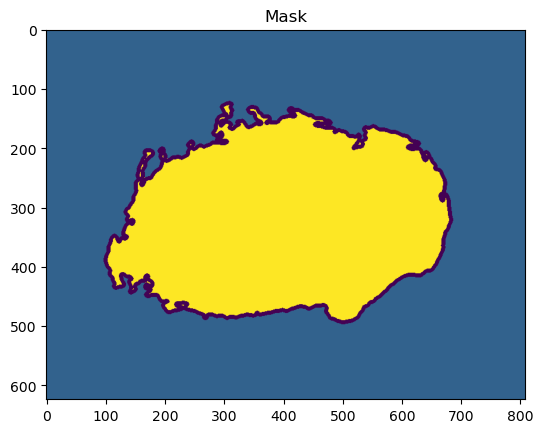

In [848]:

mass_inside=0
mass_outside=[]

#creating a mask
mask=np.zeros(OPD_dry_mass.shape, np.uint8)
contour_mask = np.zeros(OPD_dry_mass.shape, np.float64)
mask.fill(255)

#filling the mask
cv2.drawContours(mask, contours, cont_idx, (0,30,0), thickness=5)
cv2.floodFill(mask, None, (0,0), 80)
cv2.floodFill(mask, None, (len(mask[0])-1,0), 80)
cv2.floodFill(mask, None, (0,len(mask)-1), 80)
cv2.floodFill(mask, None, (len(mask[0])-1, len(mask)-1), 80)

#calculating the mass inside the mask
for i in range(len(OPD_dry_mass[0])):
    for j in range(len(OPD_dry_mass)):
        if mask[j][i]==255:
            contour_mask[j][i]=OPD_dry_mass[j][i]
            mass_inside= mass_inside+(OPD_dry_mass[j][i])
        else:
            mass_outside.append(OPD_dry_mass[j][i])

outside_max_mass=np.max(mass_outside)
outside_min_mass=np.min(mass_outside)
outside_std=np.std(mass_outside)
outside_mean_mass=np.mean(mass_outside)
contour_inside_mass=np.round((mass_inside/alpha)*dx**2, 10)

plt.imshow(mask)
plt.title("Mask")

Mass Total             : 1.8163026026
Outside Max Mass       : 126.8841530585
Outside Min Mass       : -92.4035305670
Outside Std Deviation  : 19.1367320501
Outside Mean Mass      : 7.6835296957
Contour Inside Mass    : 1.4866652270


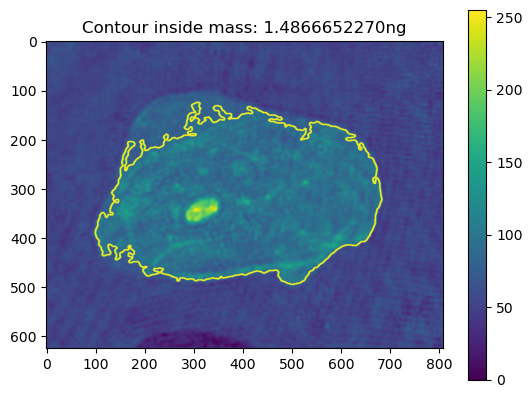

In [849]:
print(f"Mass Total             : {np.round(mass, 10):.10f}")
print(f"Outside Max Mass       : {np.max(mass_outside):.10f}")
print(f"Outside Min Mass       : {np.min(mass_outside):.10f}")
print(f"Outside Std Deviation  : {np.std(mass_outside):.10f}")
print(f"Outside Mean Mass      : {np.mean(mass_outside):.10f}")
print(f"Contour Inside Mass    : {np.round(contour_inside_mass, 10):.10f}")

plt.imshow(image_with_contours)
plt.title(f"Contour inside mass: {np.round(contour_inside_mass, 10):.10f}ng")
plt.colorbar()

### Uploading Contour from TIE Software for Comparison - Full Image

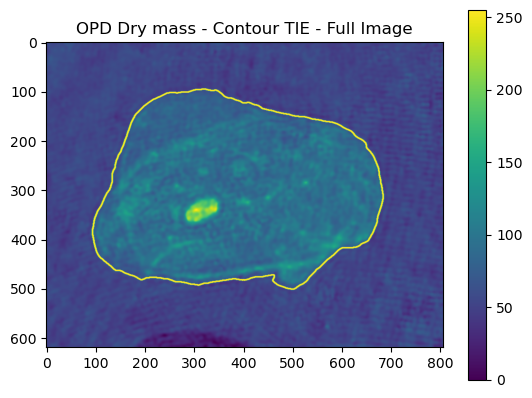

In [850]:
contour_tie = np.load(r"C:\Users\q082fh\Documents\TIE\Measurements\Measurements with DHM\Evaluation\Data 2025-05-02\Single Evaluation TIE_TIE-BG-Full_Image\TIE_TIE-BG.npy")

OPD_dry_mass_tie = OPD_dry_mass.copy()[2:621, 1:807]

img_gray_tie = cv2.normalize(OPD_dry_mass_tie, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) #OPD_dry_mass.astype(np.uint64).copy()

image_with_contours_tie = img_gray_tie.copy()
cv2.drawContours(image_with_contours_tie, contours=contour_tie, contourIdx=-1, color=(255,255,255), thickness=2, lineType=cv2.LINE_AA)

plt.imshow(image_with_contours_tie)
plt.title(f"OPD Dry mass - Contour TIE - Full Image")
plt.colorbar()

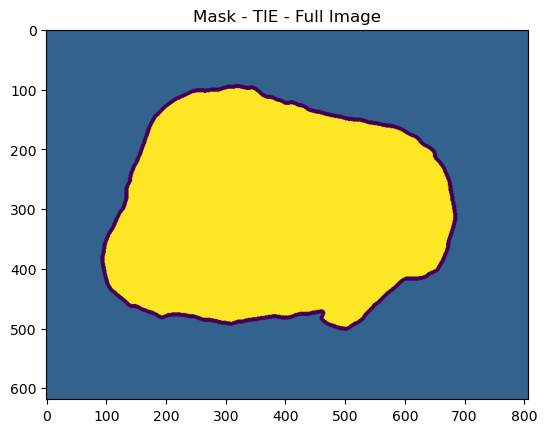

In [851]:

mass_inside=0
mass_outside=[]

#creating a mask
mask=np.zeros(OPD_dry_mass_tie.shape, np.uint8)
contour_mask = np.zeros(OPD_dry_mass_tie.shape, np.float64)
mask.fill(255)

#filling the mask
cv2.drawContours(mask, contour_tie, 0, (0,30,0), thickness=5)
cv2.floodFill(mask, None, (0,0), 80)
cv2.floodFill(mask, None, (len(mask[0])-1,0), 80)
cv2.floodFill(mask, None, (0,len(mask)-1), 80)
cv2.floodFill(mask, None, (len(mask[0])-1, len(mask)-1), 80)

#calculating the mass inside the mask
for i in range(len(OPD_dry_mass_tie[0])):
    for j in range(len(OPD_dry_mass_tie)):
        if mask[j][i]==255:
            contour_mask[j][i]=OPD_dry_mass_tie[j][i]
            mass_inside= mass_inside+(OPD_dry_mass_tie[j][i])
        else:
            mass_outside.append(OPD_dry_mass_tie[j][i])

outside_max_mass=np.max(mass_outside)
outside_min_mass=np.min(mass_outside)
outside_std=np.std(mass_outside)
outside_mean_mass=np.mean(mass_outside)
contour_inside_mass=np.round((mass_inside/alpha)*dx**2, 10)

plt.imshow(mask)
plt.title("Mask - TIE - Full Image")
plt.show()

Mass Total             : 1.8163026026
Outside Max Mass       : 80.5423833110
Outside Min Mass       : -92.4035305670
Outside Std Deviation  : 12.6324051125
Outside Mean Mass      : 3.3504664234
Contour Inside Mass    : 1.6890171291


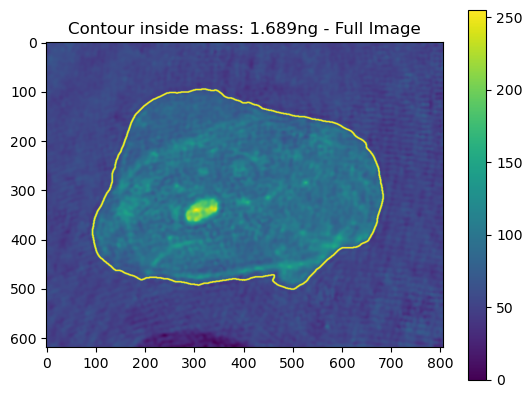

In [852]:
print(f"Mass Total             : {np.round(mass, 10):.10f}")
print(f"Outside Max Mass       : {np.max(mass_outside):.10f}")
print(f"Outside Min Mass       : {np.min(mass_outside):.10f}")
print(f"Outside Std Deviation  : {np.std(mass_outside):.10f}")
print(f"Outside Mean Mass      : {np.mean(mass_outside):.10f}")
print(f"Contour Inside Mass    : {np.round(contour_inside_mass, 10):.10f}")

plt.imshow(image_with_contours_tie)
plt.title(f"Contour inside mass: {np.round(contour_inside_mass, 4)}ng - Full Image")
plt.colorbar()
plt.show()

### Uploading Contour from TIE Software for Comparison - Cropped Image

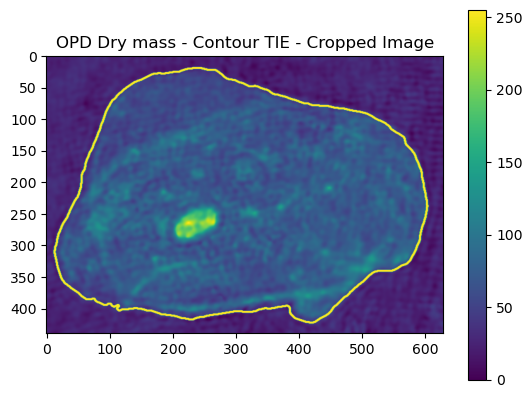

In [853]:
contour_tie = np.load(r"C:\Users\q082fh\Documents\TIE\Measurements\Measurements with DHM\Evaluation\Data 2025-05-02\Single Evaluation TIE_TIE-BG-Cropped_Image\TIE_TIE-BG.npy")

OPD_dry_mass_tie = OPD_dry_mass.copy()[77:517, 80:709]

img_gray_tie = cv2.normalize(OPD_dry_mass_tie, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) #OPD_dry_mass.astype(np.uint64).copy()

image_with_contours_tie = img_gray_tie.copy()
cv2.drawContours(image_with_contours_tie, contours=contour_tie, contourIdx=-1, color=(255,255,255), thickness=2, lineType=cv2.LINE_AA)

plt.imshow(image_with_contours_tie)
plt.title(f"OPD Dry mass - Contour TIE - Cropped Image")
plt.colorbar()
plt.show()

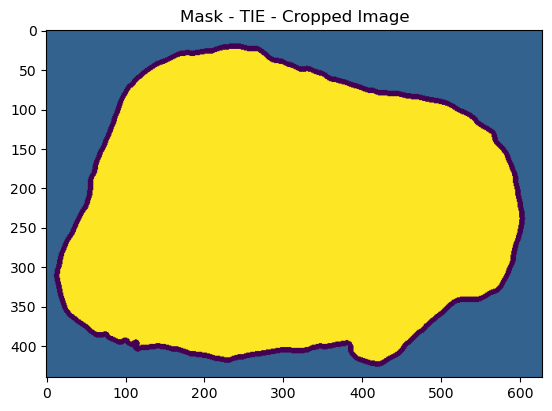

In [854]:

mass_inside=0
mass_outside=[]

#creating a mask
mask=np.zeros(OPD_dry_mass_tie.shape, np.uint8)
contour_mask = np.zeros(OPD_dry_mass_tie.shape, np.float64)
mask.fill(255)

#filling the mask
cv2.drawContours(mask, contour_tie, 0, (0,30,0), thickness=5)
cv2.floodFill(mask, None, (0,0), 80)
cv2.floodFill(mask, None, (len(mask[0])-1,0), 80)
cv2.floodFill(mask, None, (0,len(mask)-1), 80)
cv2.floodFill(mask, None, (len(mask[0])-1, len(mask)-1), 80)

#calculating the mass inside the mask
for i in range(len(OPD_dry_mass_tie[0])):
    for j in range(len(OPD_dry_mass_tie)):
        if mask[j][i]==255:
            contour_mask[j][i]=OPD_dry_mass_tie[j][i]
            mass_inside= mass_inside+(OPD_dry_mass_tie[j][i])
        else:
            mass_outside.append(OPD_dry_mass_tie[j][i])

outside_max_mass=np.max(mass_outside)
outside_min_mass=np.min(mass_outside)
outside_std=np.std(mass_outside)
outside_mean_mass=np.mean(mass_outside)
contour_inside_mass=np.round((mass_inside/alpha)*dx**2, 10)

plt.imshow(mask)
plt.title("Mask - TIE - Cropped Image")
plt.show()

Mass Total             : 1.8163026026
Outside Max Mass       : 96.0385615439
Outside Min Mass       : -36.3624378578
Outside Std Deviation  : 12.5231220094
Outside Mean Mass      : 5.4941492573
Contour Inside Mass    : 1.6789199135
Mass outside           : 0.1373826891


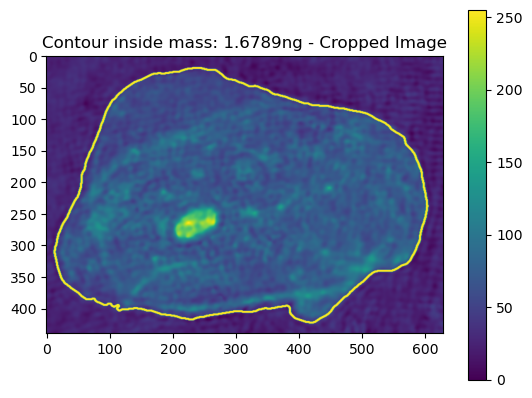

In [859]:
print(f"Mass Total             : {np.round(mass, 10):.10f}")
print(f"Outside Max Mass       : {np.max(mass_outside):.10f}")
print(f"Outside Min Mass       : {np.min(mass_outside):.10f}")
print(f"Outside Std Deviation  : {np.std(mass_outside):.10f}")
print(f"Outside Mean Mass      : {np.mean(mass_outside):.10f}")
print(f"Contour Inside Mass    : {np.round(contour_inside_mass, 10):.10f}")
print(f"Mass outside           : {np.round(mass-contour_inside_mass, 10):.10f}")

plt.imshow(image_with_contours_tie)
plt.title(f"Contour inside mass: {np.round(contour_inside_mass, 4)}ng - Cropped Image")
plt.colorbar()
plt.show()